# Latent space

NCA→t-SNE projection of the **Frozen-CLS** `[CLS]`-token embeddings on the **v10 held-out test split**.

The paper applies a two-step supervised dimensionality reduction: Neighborhood Components Analysis (NCA) projects the 256-d `[CLS]` embeddings to a low-dimensional metric space using the cell-type labels, then t-SNE embeds the NCA output to 2-D. The **same 2-D coordinates** are reused for all three colorings (cell type, imaging modality, tissue) so the panels are geometrically identical and differ only in the hue assignment. Styled to the Science Advances 2026 figure spec via `dct_figures.style`.

Reproduces `latent_celltype_final_frozen_cls_nca_tsne`, `latent_modality_final_frozen_cls_nca_tsne`, and `latent_tissue_final_frozen_cls_nca_tsne`.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd()))   # ensure dct_figures importable
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
from dct_figures import paths, style, colors
style.apply_style()

## Load embeddings + stratified subsample

Loads the `[CLS]`-token embedding NPZ (`cls_token_embedding`, `ct_str`, `domain_str`) and the per-cell tissue sidecar (`cls_token_meta_final_frozen_cls.npz`, key `tissue`, in identical loader order). We then take a **stratified subsample by (cell_type, modality) pair** (seed 42, `n_samples=10000`) so rare cell types survive and every (CT, modality) combo appears with similar weight — mirroring `analysis/plot_tsne.py`.

In [2]:
import yaml

N_SAMPLES = 10000          # plot_tsne.py default
SUBSAMPLE_SEED = 42        # rng for stratified pair subsample

emb_npz = paths.need(paths.OUTPUT / 'cls_token_embedding_final_frozen_cls.npz')
meta_npz = paths.need(paths.OUTPUT / 'cls_token_meta_final_frozen_cls.npz')

data = np.load(str(emb_npz), allow_pickle=True)
cls = data['cls_token_embedding']
dom = np.array([str(s) for s in data['domain_str']])
cts = np.array([str(s) for s in data['ct_str']])

meta = np.load(str(meta_npz), allow_pickle=True)
tissue_all = np.array([str(s) for s in meta['tissue']])
assert len(tissue_all) == len(cls), 'tissue meta length mismatch'

# Stratified subsample by (cell_type, modality) pair (NOT cell_type alone),
# so each (CT, modality) combo appears with similar weight.
rng = np.random.default_rng(SUBSAMPLE_SEED)
if N_SAMPLES < len(cls):
    pair_keys = np.array([f'{c}|{d}' for c, d in zip(cts, dom)])
    unique_pairs = np.unique(pair_keys)
    per_pair = max(1, int(np.ceil(N_SAMPLES / max(1, len(unique_pairs)))))
    picked = []
    for pk in unique_pairs:
        pair_idx = np.where(pair_keys == pk)[0]
        take = min(per_pair, len(pair_idx))
        picked.append(rng.choice(pair_idx, size=take, replace=False))
    idx = np.concatenate(picked)
    if len(idx) > N_SAMPLES:
        idx = rng.choice(idx, size=N_SAMPLES, replace=False)
    cls, dom, cts = cls[idx], dom[idx], cts[idx]
    tissue_all = tissue_all[idx]

print(f'{len(cls):,} cells subsampled | {len(np.unique(cts))} cell types | '
      f'{len(np.unique(dom))} modalities | {len(np.unique(tissue_all))} tissues')

8,900 cells subsampled | 33 cell types | 4 modalities | 8 tissues


## Compute the NCA→t-SNE projection (once)

Per-feature z-score, then **NCA** (`n_components=8`, `max_iter=100`, `tol=1e-6`, `random_state=0`) supervised on cell-type labels (classes with <2 samples dropped, as NCA requires), then **t-SNE** (`perplexity=150`, `early_exaggeration=4.0`, `init='pca'`, `learning_rate='auto'`, `max_iter=2000`, `random_state=0`). All seeds match `analysis/plot_tsne.py`. This is the expensive step — it runs **once** and the resulting 2-D coords are reused by every panel below.

In [3]:
from sklearn.manifold import TSNE
from sklearn.neighbors import NeighborhoodComponentsAnalysis

NCA_DIM = 8                # plot_tsne.py --nca_dim default
NCA_MAX_ITER = 100         # plot_tsne.py --nca_max_iter default
PERPLEXITY = 150           # plot_tsne.py --perplexity default
EARLY_EXAGGERATION = 4.0   # plot_tsne.py --early_exaggeration default

# Per-feature z-score (matches plot_tsne.py).
X = cls - cls.mean(axis=0, keepdims=True)
std = X.std(axis=0, keepdims=True)
std[std == 0] = 1.0
X = X / std

# NCA needs >=2 samples per class; drop singleton classes.
labels, ct_int = np.unique(cts, return_inverse=True)
keep = np.bincount(ct_int) >= 2
keep_rows = keep[ct_int]
X_f = X[keep_rows]
ct_f = ct_int[keep_rows]
# Subset the label arrays in lock-step so colorings line up with coords.
dom = dom[keep_rows]
cts = cts[keep_rows]
tissue_all = tissue_all[keep_rows]

n_components = min(NCA_DIM, X_f.shape[1] - 1)
print(f'Running NCA: {X_f.shape} -> {n_components}d (max_iter={NCA_MAX_ITER})')
nca = NeighborhoodComponentsAnalysis(
    n_components=n_components, max_iter=NCA_MAX_ITER,
    tol=1e-6, random_state=0)
x_proj = nca.fit_transform(X_f, ct_f)

print(f'Running t-SNE on {x_proj.shape} (perplexity={PERPLEXITY}, '
      f'early_exaggeration={EARLY_EXAGGERATION})')
tsne = TSNE(n_components=2, random_state=0, perplexity=PERPLEXITY,
            early_exaggeration=EARLY_EXAGGERATION,
            init='pca', learning_rate='auto', max_iter=2000)
emb_2d = tsne.fit_transform(x_proj)

# Single shared coords dataframe reused by all three colorings.
df = pd.DataFrame({
    'x': emb_2d[:, 0], 'y': emb_2d[:, 1],
    'modality': dom, 'cell_type': cts, 'tissue': tissue_all,
})
print(f'2-D coords: {df.shape[0]:,} cells')

Running NCA: (8900, 256) -> 8d (max_iter=100)


Running t-SNE on (8900, 8) (perplexity=150, early_exaggeration=4.0)


2-D coords: 8,900 cells


### Shared scatter helper

`_scatter` is lifted verbatim from `analysis/plot_tsne.py`: a small, alpha-blended seaborn scatter with a full categorical legend, tab20-backfilled for any label missing from the supplied palette. The cell-type palette is the colorblind-safe lineage ramp from `dct_figures.colors.celltype_color_mapping`.

In [4]:
import matplotlib.colors
from dct_figures.style import COL_2, style_ax
from dct_figures.colors import celltype_color_mapping

# celltype_color_mapping wants an object exposing `.lineage_mapping`;
# the torch-bound TissueNetConfig isn't available in the notebook env, so
# build a tiny shim from the vendored lineage taxonomy.
with open(paths.DATA_ROOT / 'lineage_mapping.yaml') as fh:
    _lineage_mapping = yaml.safe_load(fh)

class _ConfigShim:
    lineage_mapping = _lineage_mapping

CT_PALETTE = celltype_color_mapping(_ConfigShim())


def _tissue_palette(levels):
    """Categorical palette for tissues (tab20 -> tab20b -> tab20c)."""
    cmaps = [plt.get_cmap('tab20'), plt.get_cmap('tab20b'),
             plt.get_cmap('tab20c')]
    pal = {}
    for i, lvl in enumerate(levels):
        cmap = cmaps[i // 20]
        pal[lvl] = matplotlib.colors.to_hex(cmap(i % 20))
    return pal


def _scatter(ax, df, hue_col, palette):
    # Backfill any missing keys with tab20 so legacy CT names don't crash.
    if isinstance(palette, dict):
        levels = sorted(df[hue_col].unique())
        missing = [k for k in levels if k not in palette]
        if missing:
            tab = plt.get_cmap('tab20', max(len(missing), 1))
            palette = dict(palette)
            for i, k in enumerate(missing):
                palette[k] = matplotlib.colors.to_hex(tab(i % 20))
    sns.scatterplot(x='x', y='y', hue=hue_col, data=df, palette=palette,
                    ax=ax, s=1, alpha=0.7, edgecolor='none', legend='full')
    ax.set_xlabel(''); ax.set_ylabel('')
    ax.set_xticks([]); ax.set_yticks([])
    style_ax(ax, grid_axis=None)
    leg = ax.get_legend()
    if leg is not None:
        leg.set_bbox_to_anchor((1.02, 1))
        leg.get_frame().set_alpha(0.95)
        handles = getattr(leg, 'legend_handles', None) or leg.legendHandles
        for h in handles:
            if hasattr(h, 'set_sizes'):
                h.set_sizes([30])
            if hasattr(h, 'set_markersize'):
                h.set_markersize(5)

## latent_celltype_final_frozen_cls_nca_tsne

*caption:* NCA→t-SNE projection of Frozen-CLS [CLS] embeddings, colored by cell type.

/tmp/claude-1011/ipykernel_2162822/2557138905.py:4: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout()


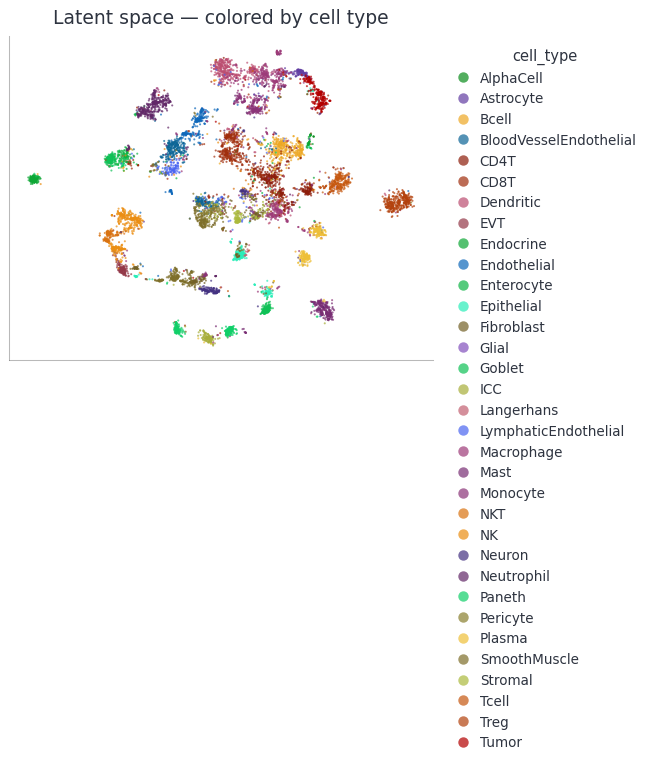

In [5]:
fig, ax = plt.subplots(figsize=(COL_2 * 0.5, COL_2 * 0.5 * 0.77))
_scatter(ax, df, 'cell_type', CT_PALETTE)
ax.set_title('Latent space — colored by cell type')
fig.tight_layout()
plt.show()

## latent_modality_final_frozen_cls_nca_tsne

*caption:* NCA→t-SNE projection of Frozen-CLS [CLS] embeddings, colored by modality.

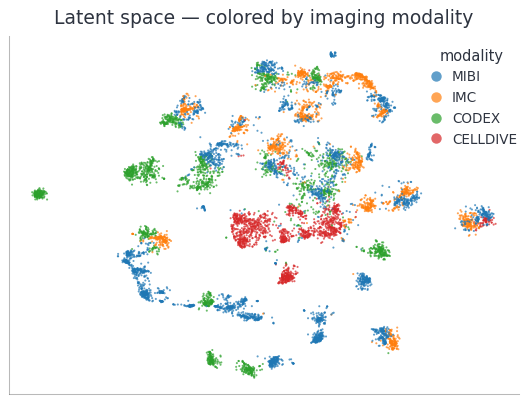

In [6]:
fig, ax = plt.subplots(figsize=(COL_2 * 0.5, COL_2 * 0.5 * 0.77))
_scatter(ax, df, 'modality', None)
ax.set_title('Latent space — colored by imaging modality')
fig.tight_layout()
plt.show()

## latent_tissue_final_frozen_cls_nca_tsne

*caption:* NCA→t-SNE projection of Frozen-CLS [CLS] embeddings, colored by tissue.

Tissues are sorted by frequency (most common first) and painted abundant→rare so rare tissues land on top, matching the modality panel's visual order.

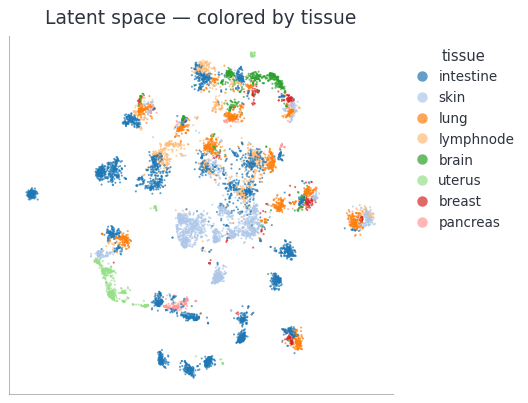

In [7]:
from collections import Counter

counts = Counter(df['tissue'].tolist())
tissue_levels = [t for t, _ in counts.most_common()]
tissue_rank = {t: i for i, t in enumerate(tissue_levels)}
order = np.argsort([-tissue_rank[t] for t in df['tissue'].tolist()])
df_t = df.iloc[order].reset_index(drop=True)
df_t['tissue'] = pd.Categorical(df_t['tissue'], categories=tissue_levels,
                                ordered=True)
tissue_pal = _tissue_palette(tissue_levels)

fig, ax = plt.subplots(figsize=(COL_2 * 0.5, COL_2 * 0.5 * 0.77))
_scatter(ax, df_t, 'tissue', tissue_pal)
ax.set_title('Latent space — colored by tissue')
fig.tight_layout()
plt.show()